# Archetype Crosstalk Network

Adapted from {cite:p}`Adler2023`

## Packages

To run this notebook, install ParTIpy with the tutorial extras: `pip install partipy[extra]`.

In [ ]:
import scanpy as sc
import liana as li
import pandas as pd

import partipy as pt
from partipy.datasets import load_fibroblast_data
from partipy.crosstalk import get_specific_genes_per_archetype, get_archetype_crosstalk, plot_weighted_network

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Data

Here we use the data from {cite:p}`muhlSinglecellAnalysisUncovers2020`.

In [ ]:
adata = load_fibroblast_data(
    verbose=True,
)
adata

Loading processed data from data/fibroblast_muhl_processed.h5ad


AnnData object with n_obs × n_vars = 1374 × 17790

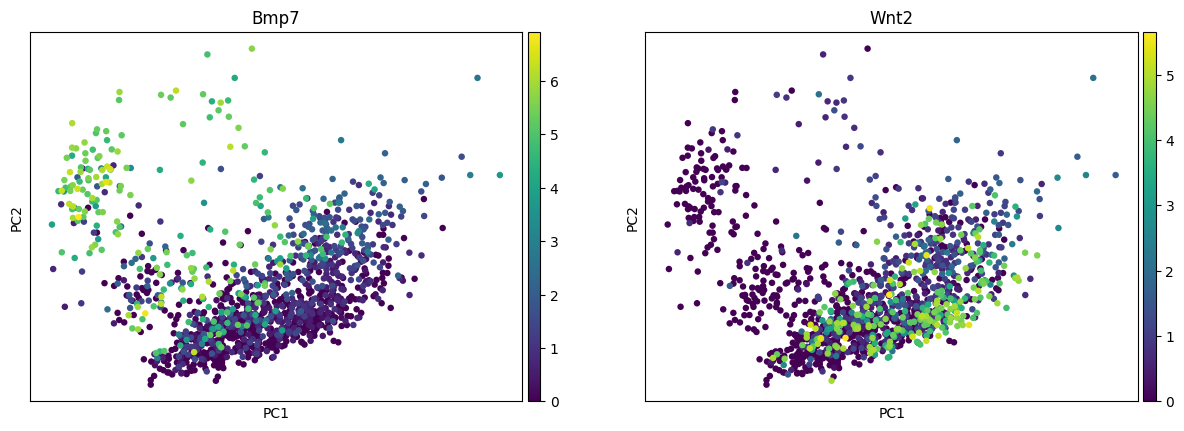

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable", n_comps=50)
adata.layers["z_scaled"] = sc.pp.scale(adata.X, max_value=10, copy=True)  # save this for later
sc.pl.pca_scatter(adata, color=["Bmp7", "Wnt2"])

Based on the PCA scree plot, we will be using 8 PC dimensions to fit the archetypes.

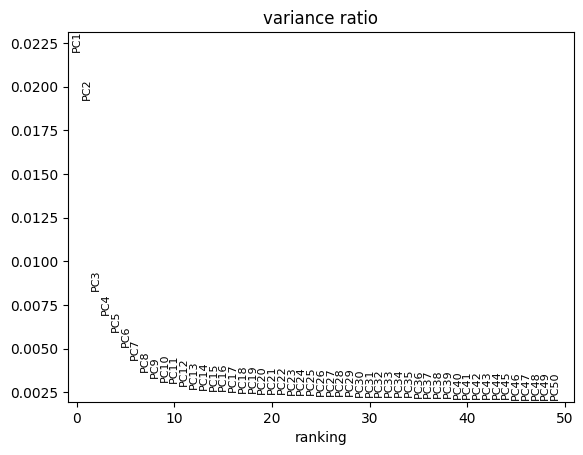

In [4]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=8)

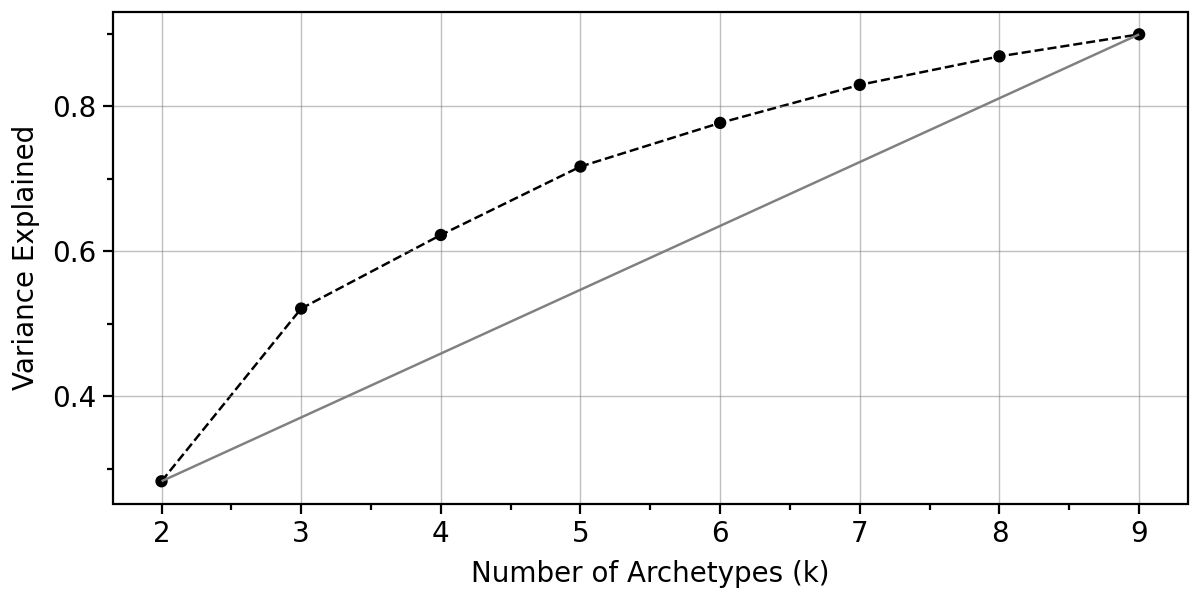

In [5]:
pt.compute_selection_metrics(adata=adata, n_archetypes_list=range(2, 10))
pt.plot_var_explained(adata).show()

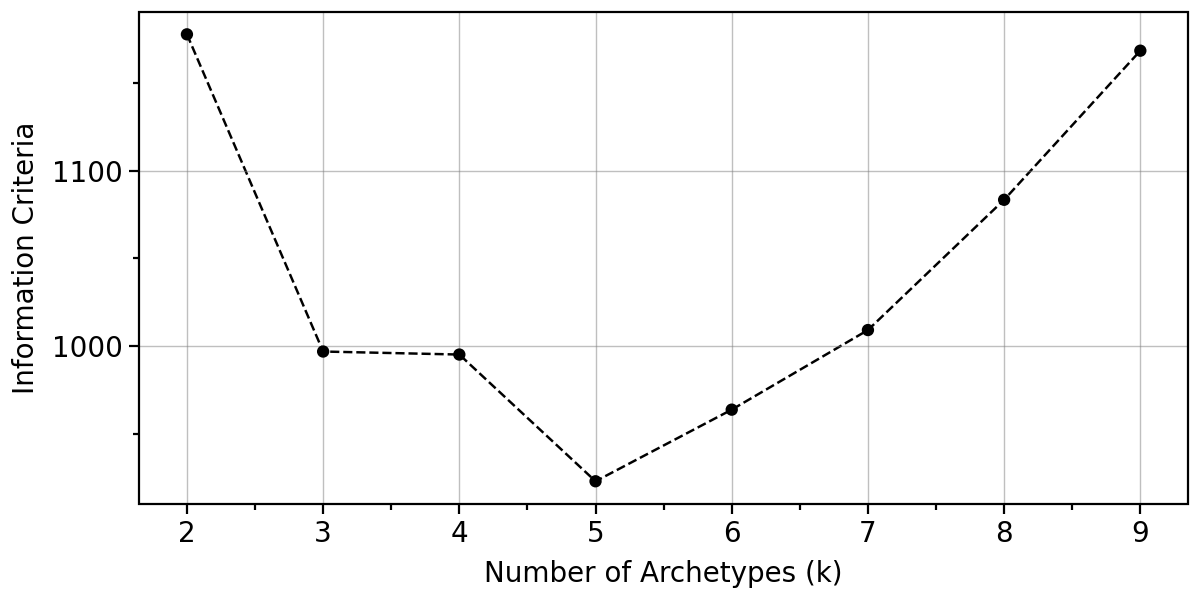

In [6]:
pt.plot_IC(adata).show()

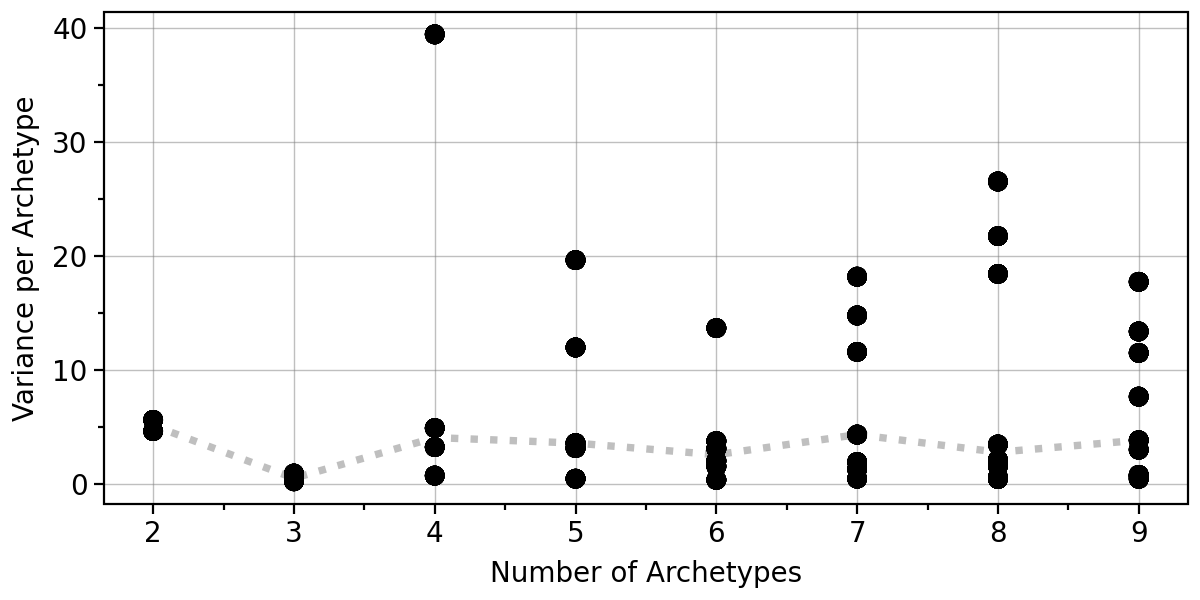

In [7]:
pt.compute_bootstrap_variance(adata, n_bootstrap=30, n_archetypes_list=range(2, 10))
pt.plot_bootstrap_variance(adata)

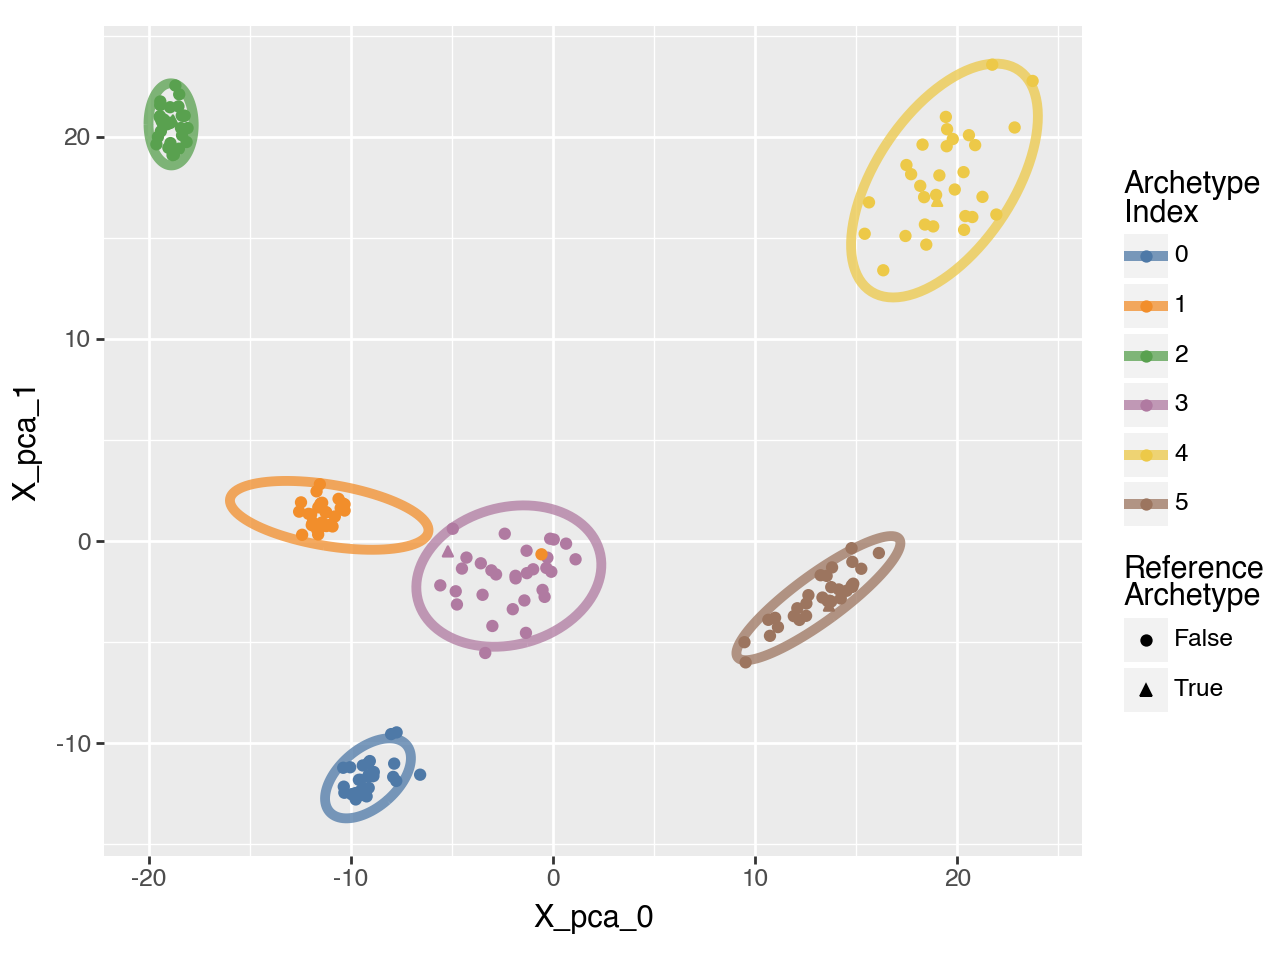

In [8]:
pt.plot_bootstrap_2D(adata, result_filters={"n_archetypes": 6})

Here, we will use 5 archetypes. When fitting 4 archetypes we have observed that running archetypal analysis on bootstrapped data shows that one archetype is quite unstable, whereas using 5 worked much better.

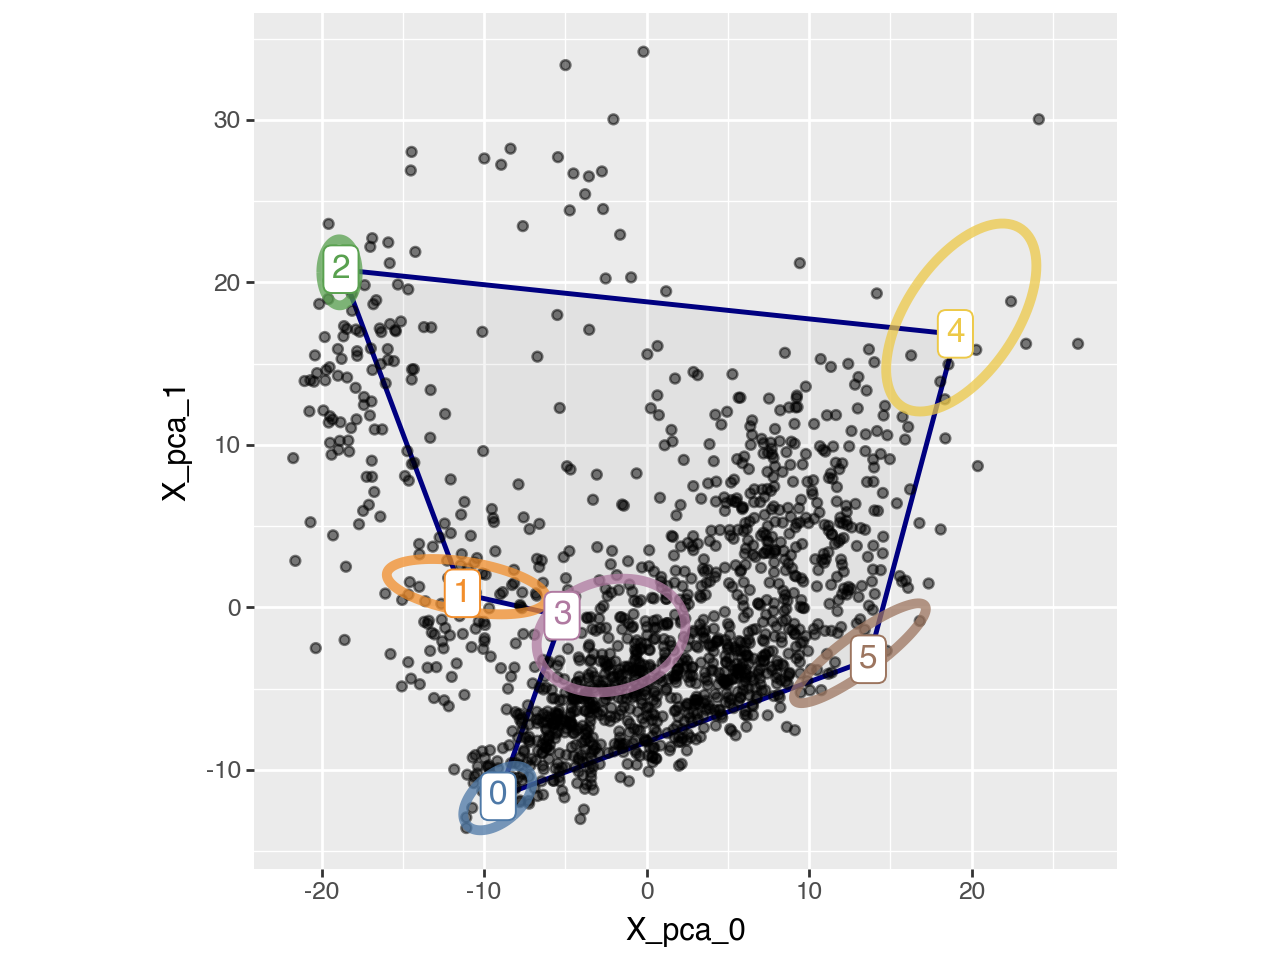

In [9]:
pt.plot_archetypes_2D(adata=adata, show_contours=True, result_filters={"n_archetypes": 6})

Determine which genes are characteristic for each archetype

Applied length scale is 12.34.


/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


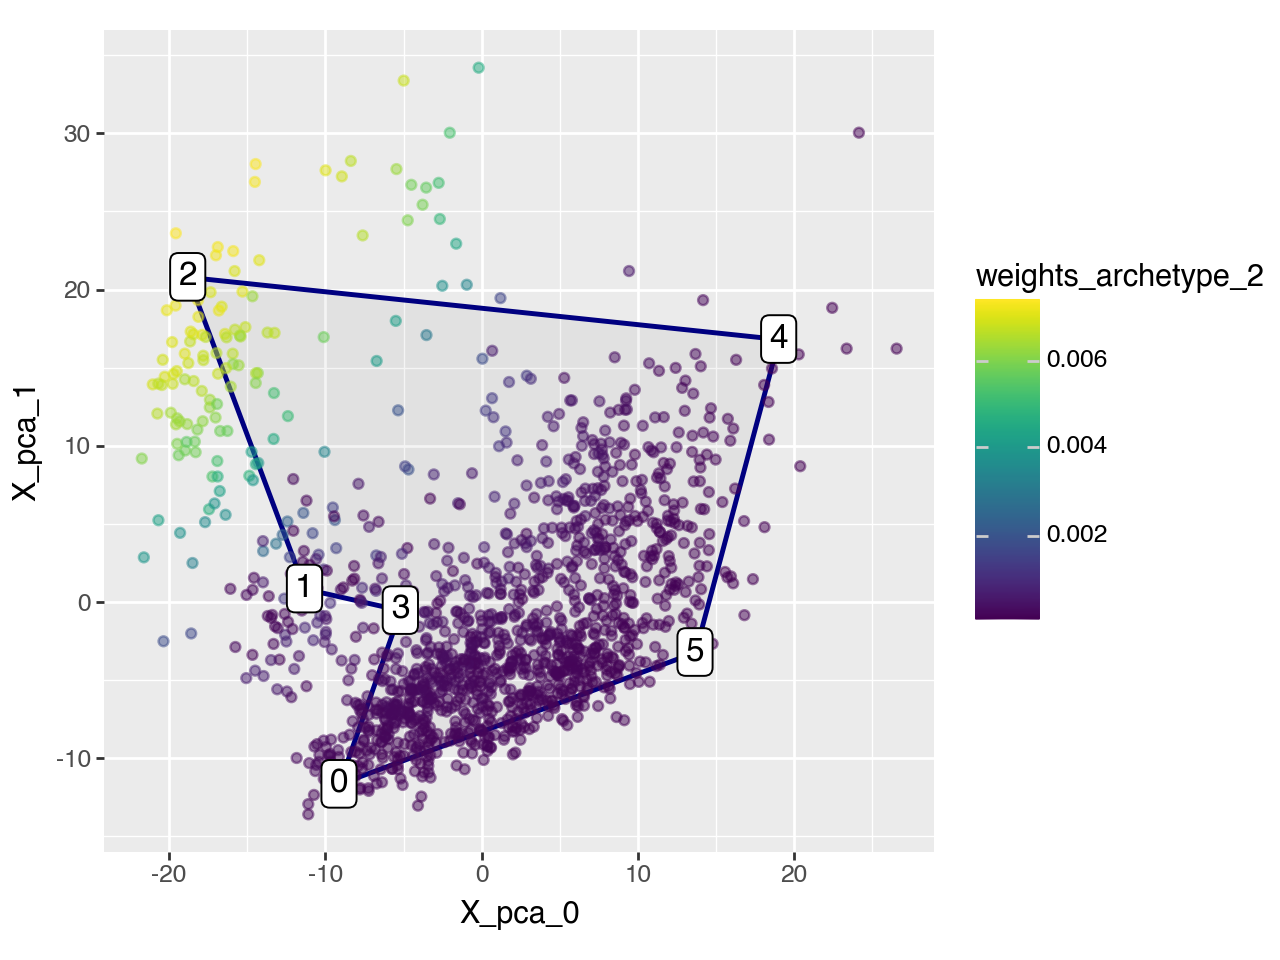

In [10]:
pt.compute_archetype_weights(adata=adata, mode="automatic", result_filters={"n_archetypes": 6})
pseudobulk = pt.compute_archetype_expression(adata=adata, layer="z_scaled", result_filters={"n_archetypes": 6})

arch_idx = 2
adata.obs[f"weights_archetype_{arch_idx}"] = pt.get_aa_cell_weights(adata, n_archetypes=6)[:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}", result_filters={"n_archetypes": 6})

In [11]:
specific_genes_per_archetype = get_specific_genes_per_archetype(archetype_expression=pseudobulk, min_score=0.05)

[(arch_id, len(arch_genes)) for arch_id, arch_genes in specific_genes_per_archetype.items()]

[(0, 12), (1, 1173), (2, 1722), (3, 760), (4, 4871), (5, 1381)]

Based on the genes we infer the functions of each archetype

In [12]:
for i in range(len(specific_genes_per_archetype)):
    print(i, specific_genes_per_archetype[i].head(25)["gene"].to_list())

0 ['Serping1', 'Bcl6', 'Zfp808', 'Itm2b', 'Ms4a4d', 'Rax', 'C1rb', 'Gm2237', 'Hoxc10', 'Gm7670', 'Gm23119', 'Cyp1b1']
1 ['Lmod1', 'Cnn1', 'Actg2', 'Cdh6', 'Pdgfc', 'Myocd', 'Itga8', 'Asb2', 'Myh11', 'Trpc6', 'Kcnmb1', 'Tnfrsf19', 'Tspan2', 'Acta1', 'Tagln', 'Pcp4l1', 'Slc2a4', 'Hspb7', 'Gm16000', 'Pde6h', 'Ctxn1', 'Hhip', 'Ptk2b', 'Cacna1h', 'Sntg2']
2 ['Nrg1', 'Cd38', '1700071M16Rik', 'Lef1', 'Lpar3', 'Lef1os1', 'Trpa1', 'Pla2g7', 'Lama5', 'Cdhr17', 'Rab3b', 'Ano2', 'Ptprr', 'C5ar1', 'Glp2r', 'Cd300e', 'Abcc4', 'Tbx3', 'Sema4d', 'Paqr5', 'Insc', 'Eva1a', 'Ednrb', 'Procr', 'Ano1']
3 ['Efnb2', 'Gm42721', 'Ugcg', 'Pde1c', 'Gm37515', 'Gm31258', '1700082M22Rik', 'Gm42785', 'Gm37954', 'Ryr3', 'Bmp3', 'Gm43577', 'Gm42513', 'Gm44153', 'Gm4117', 'Kcnq1ot1', 'Macrod2os1', 'Ksr2', 'Gm17131', 'Gm37315', 'Ddx17', 'Mir6240', 'Pkib', 'Gm12018', 'Gm37086']
4 ['Sox18', 'Mmrn2', 'Robo4', 'Ushbp1', 'Tie1', 'Plvap', 'Flt1', 'Kdr', 'Emcn', 'Egfl7', 'Podxl', 'Dll4', 'Cd300lg', 'Depp1', 'Adgrl4', 'Gdf10', '

In [ ]:
archetype_functions = {
    0: "ECM-remodeling fibroblasts",
    1: "Vascular-associated fibroblasts",
    2: "Neuronal/epithelial-interacting fibroblasts",
    3: "Myofibroblasts",
    4: "Immune-modulatory fibroblasts",
}

Finally we use [LIANA+](https://liana-py.readthedocs.io/en/latest/) to infer ligand and receptor are enriched between archetypes.

In [14]:
mouse_resource = li.rs.select_resource("mouseconsensus")
mouse_resource

,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3
...,...,...
35355,Serpina1a,Lrp1
35356,Serpina1b,Lrp1
35357,Serpina1c,Lrp1
35358,Serpina1d,Lrp1


In [ ]:
archetype_crosstalk = get_archetype_crosstalk(archetype_genes=specific_genes_per_archetype, lr_resource=mouse_resource)
for sender_arch in archetype_crosstalk.keys():
    for receiever_arch in archetype_crosstalk[sender_arch].keys():
        print(f"{sender_arch} -> {receiever_arch}: {len(archetype_crosstalk[sender_arch][receiever_arch])}")
    break

0 -> 0: 0
0 -> 1: 0
0 -> 2: 0
0 -> 3: 0
0 -> 4: 1
0 -> 5: 0


The corresponding flattened version looks like this:

In [ ]:
flat_df = pd.concat(
    [
        df.assign(sender_archetype=sender_arch, receiver_archetype=receiver_arch)
        for sender_arch, receivers in archetype_crosstalk.items()
        for receiver_arch, df in receivers.items()
    ],
    ignore_index=True,
)
flat_df

,ligand,receptor,ligand_z_score,ligand_specificity_score,receptor_z_score,receptor_specificity_score,sender_archetype,receiver_archetype
0,Serping1,Lrp1,0.205085,0.154098,0.366762,0.080052,0,4
1,Sema5a,Met,0.568509,0.403587,1.126435,0.970279,1,1
2,Lgals1,Itgb1,0.127651,0.062814,0.573087,0.474441,1,1
3,Vegfb,Adrb2,0.282850,0.242285,0.419965,0.250148,1,1
4,Tln1,Itgb3,0.250728,0.074158,0.499605,0.385054,1,1
...,...,...,...,...,...,...,...,...
763,C3,Cd81,0.549103,0.142512,0.564969,0.195734,5,5
764,Adam10,Tspan5,0.156096,0.086548,0.212523,0.063955,5,5
765,Lamc2,Cd151,0.250121,0.133691,0.228000,0.119776,5,5
766,Wnt11,Klrg2,0.232272,0.201278,0.081127,0.103476,5,5


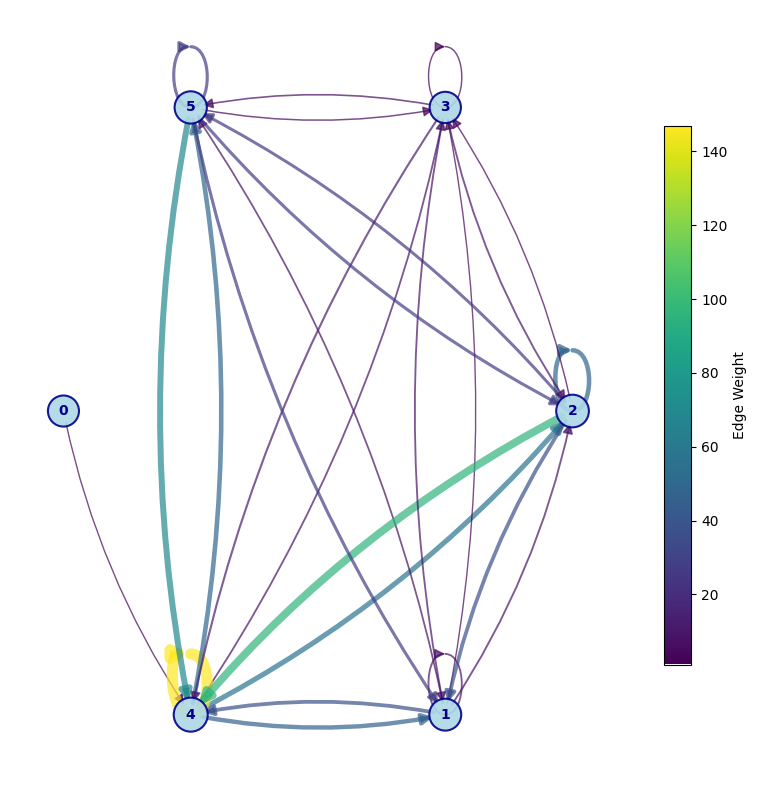

In [ ]:
plot_weighted_network(
    specific_genes_per_archetype=specific_genes_per_archetype,
    archetype_crosstalk_dict=archetype_crosstalk,
    layout="shell",
    seed=42,
)

## Session Info

In [ ]:
import session_info2

print(session_info2.session_info(dependencies=True))

pandas	2.2.3
plotnine	0.14.5
scanpy	1.11.2
liana	1.5.1
partipy	0.2.0 (0.0.1)
anndata	0.11.4
----	----
dask	2024.11.2
natsort	8.4.0
cattrs	24.1.3
pytz	2025.2
crc32c	2.7.1
debugpy	1.8.14
stack-data	0.6.3
mizani	0.13.5
charset-normalizer	3.4.2
wcwidth	0.2.13
psutil	7.0.0
future	1.0.0
certifi	2025.4.26 (2025.04.26)
parso	0.8.4
ipykernel	6.29.5
torch	2.10.0
typing-inspection	0.4.2
cycler	0.12.1
ipython	9.2.0
tornado	6.5.1
narwhals	1.41.0
urllib3	2.4.0
matplotlib	3.10.3
setuptools	80.8.0
idna	3.10
networkx	3.5
scipy	1.15.2
legacy-api-wrap	1.4.1
MarkupSafe	3.0.3
scikit-learn	1.6.1
Jinja2	3.1.6
docrep	0.3.2
pydantic	2.12.0
zstandard	0.25.0
prompt_toolkit	3.0.51
numpy	2.2.6
python-dateutil	2.9.0.post0
appnope	0.1.4
coverage	7.10.7
importlib_metadata	8.7.0
numba	0.61.2
mudata	0.3.2
attrs	25.3.0
matplotlib-inline	0.1.7
toolz	1.0.0
llvmlite	0.44.0
jedi	0.19.2
requests-cache	1.2.1
h5py	3.13.0
pillow	11.2.1
numcodecs	0.15.1
typing_extensions	4.15.0
pyarrow	20.0.0
asttokens	3.0.0
jupyter_client	8.6.3